# Tutorial: Convolutional Autoencoder (CAE)
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> H. B. Prosper<br>

## Introduction
In this tutorial, we explore an autoencoder variation called a convolutional autoencoder (CAE) to compress galaxy images. The galaxy image dataset of 04.CNN, namely, the 12,600 images with each image cropped to $96\times96$ pixels, is used.

## Model

In a CAE, both the encoder $h(x) \rightarrow z$ and the decoder $g(z) \rightarrow x$ are convolutional neural networks. The encoder compresses the image, while the decoder expands the compressed image using the function $\texttt{ConvTranspose2d}$. It is simpler to understand that function with an example. Consider a single-channel image of shape ($H=6$, $W=6$) and a kernel with filters of shape ($H_F = 2$, $W_F = 2$). In the simplest case, which we use here, the size of the output image is given  by
\begin{align}
H_\text{out} & = (H - 1) \times S + H_F, \\
W_\text{out} & = (W - 1) \times S + W_F ,
\end{align}
where $S$ is the stride over the output image. If we choose $H_F = W_F = S$, the output image size will be $S$ times as large in both height and width as the input image. Therefore, if we choose $S = 2$, that is, filters of shape $(2, 2)$, an image of shape $(6, 6)$ will be mapped to one of shape $(12, 12)$. In effect, each input pixel is magnified to an image of shape $(2, 2)$, but with a crucial twist: the image of the input pixel varies across the $S \times S$ pixels. This is done by multiplying the input pixel value by each element of the filter. Since, in general, the elements of a filter differ, the magnified image of a given pixel will differ from the original pixel. This of course is necessary to recover the original image.

## Running on Google Colab
If on Google Colab (https://colab.research.google.com), execute cell below.

In [1]:
try:
    import google.colab

    REPO = 'hbprosper/mlinphysics'
    
    url = f"https://raw.githubusercontent.com/{REPO}/refs/heads/main"
    !wget -q {url}/clone2colab.ipynb -O clone2colab.ipynb
    %run clone2colab.ipynb
    
    IN_COLAB = True
    
except ImportError:
    
    IN_COLAB = False

In [2]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# to reimport Python modules
import importlib

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn
import torch.nn.functional as F

# module to reimport Python modules
import importlib

import h5py

# module for shell utilities
import shutil

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon

from tqdm import tqdm

# update fonts
plt.rcParams.update({
  "text.usetex": shutil.which('latex') is not None,
  "font.family": "sans-serif",
  "font.sans-serif": "Helvetica",
  "font.size": 14
})

## Computational Device

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tAvailable device: {str(DEVICE):4s}\n')


	Available device: cpu 



## Load Galaxy Images
Load galaxy images and normalize pixels by dividing each by 256.

In [4]:
#                0, 1, 2, 3
# change shape: (N, C, H, W) => (N, H, C, W) => (N, H, W, C)
def to_images(x):
    images = x.transpose(1,2).transpose(2,3).data.cpu().numpy()
    return images

def load_images(filename='../data/galaxy10.h5'):
    with h5py.File(filename, 'r') as F:
        images = np.array(F['images']).astype(np.float32)/256 # normalize pixels
        labels = np.array(F['labels']).astype(np.long)        # class labels
    return images, labels

def plot_images(images, targets, K=0,
                n_rows=4,
                n_cols=5, filename='galaxies.png'):

    f_size = (4, n_rows * 0.8)

    if type(images) == type(torch.Tensor()):
        imgs = to_images(images)
    else:
        imgs = images

    fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=f_size)

    # note use of flatten() to convert the matrix
    # of shape (nrows, ncols) to a 1-d array.
    axs = axs.flatten()
    n = len(axs)

    # use "zip" to create an list of shape (N, 3)
    for image, target, ax in zip(imgs[K:K+n], targets[K:K+n], axs):

        ax.axis('off')

        ax.imshow(image)

        # Note: (x, y) coordinates are in pixels,
        # where (0, 0) is the upper left corner
        ax.text(8, 16, f'{target:d}', color='white', fontsize=10)

    plt.savefig(filename)

    #plt.show()

number of images: 12600


((12600, 96, 96, 3), (12600,))

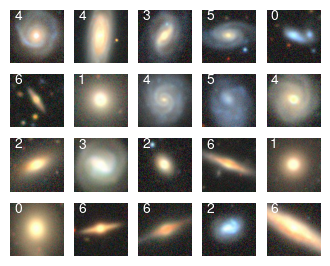

In [5]:
images, targets = load_images()

print(f'number of images: {len(images):d}')

plot_images(images, targets)

images.shape, targets.shape

## Configuration

In [6]:
# name of model
name = 'CAE'

# create new configuration
config = mlp.Config(name, dirname='CAE')

batch_size = 256
train_size = 10_240
test_size  = 1400
val_size   = len(images) - train_size - test_size

# nominal number of iterations
n_iterations = 200_000

# number of iterations per epoch
n_iters_per_epoch = int(np.ceil(train_size / batch_size))

# number of epochs
n_epochs = int(np.ceil(n_iterations / n_iters_per_epoch))

# exact number of iterations
n_iterations = n_epochs * n_iters_per_epoch

# number of steps with a fixed learning rate
n_steps  = 2

# number of iterations per step
n_iters_per_step =  int(n_iterations / n_steps)

# training configuration
# -----------------------------------------
config('train_size', train_size) # training sample size
config('test_size',  test_size)  # test sample size
config('val_size',   val_size)   # validation sample size
config('batch_size', batch_size)

config('monitor_step',   100)    # monitor training every n (=10) iterations
config('delete', True)           # delete losses file before training, if True
config('frac', 0.015)            # save model if average loss decreases by more
                                 # than frac percent

# optimizer / scheduler configuration
# -----------------------------------------
# a step comprises a given number of iterations
config('n_iterations', n_iterations)
config('n_steps', n_steps)       # number of training steps
config('n_iters_per_step', n_iters_per_step)
config('n_epochs',   n_epochs)
config('n_iters_per_epoch', n_iters_per_epoch)
config('base_lr', 1.e-3)         # initial learning rate
config('gamma', 0.8)             # learning rate scale factor

print(f'\nSave configuration to file {config('file/config')}\n')
config.save()

print(config)


Save configuration to file runs/CAE/CAE_config.yaml

name: CAE
file:
  config: runs/CAE/CAE_config.yaml
  losses: runs/CAE/CAE_losses.csv
  params: runs/CAE/CAE_params.pth
  init_params: runs/CAE/CAE_init_params.pth
  plots: runs/CAE/CAE_plots.png
train_size: 10240
test_size: 1400
val_size: 960
batch_size: 256
monitor_step: 100
delete: true
frac: 0.015
n_iterations: 200000
n_steps: 2
n_iters_per_step: 100000
n_epochs: 5000
n_iters_per_epoch: 40
base_lr: 0.001
gamma: 0.8



## Prepare Datasets and DataLoaders
  1. change shape ( (N, H, W, C) => (N, C, H, W) )
  3. Split data into training, testing, and validation sets.

### Datasets

In [25]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# change shape ( (N, H, W, C) => (N, C, H, W) )
data = images.transpose(0, 3, 1, 2)

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(data,
                         start=0,
                         end=train_size,
                         targets=targets)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(data,
                             start=0,
                             end=train_size,
                             random_sample_size=val_size,
                             targets=targets)

# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(data,
                       start=train_size,
                       end=train_size + val_size,
                       targets=targets)

# test dataset
print('test data')
test_data= dat.Dataset(data,
                       start=train_size + val_size,
                       end=train_size + val_size + test_size,
                       targets=targets)

training data
Dataset
  shape of x: torch.Size([10240, 3, 96, 96])
  shape of y: torch.Size([10240])

training data for validation
Dataset
  shape of x: torch.Size([960, 3, 96, 96])
  shape of y: torch.Size([960])

validation data
Dataset
  shape of x: torch.Size([960, 3, 96, 96])
  shape of y: torch.Size([960])

test data
Dataset
  shape of x: torch.Size([1400, 3, 96, 96])
  shape of y: torch.Size([1400])



### DataLoaders

In [26]:
import torch.utils.data as td

print('train data loader')
train_loader = td.DataLoader(train_data, batch_size=config('batch_size'))
print('iterations / epoch:', len(train_loader))
print()

print('train data loader for validation')
train_loader_val = td.DataLoader(train_data_val, batch_size=len(train_data_val))

print('validation data loader')
val_loader = td.DataLoader(val_data, batch_size=len(val_data))

print('test data loader')
test_loader = td.DataLoader(test_data, batch_size=len(test_data))

train data loader
iterations / epoch: 40

train data loader for validation
validation data loader
test data loader


## Build Model

The `ConvBlock` and `ConvTBlock` decrease and increase the input image size by a factor 2, respectively.

In [28]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 activation=nn.ReLU()):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=in_channels,
                      out_channels=out_channels,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            activation,
            nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        )
    def forward(self, x):
        x = self.net(x)
        return x

class ConvTBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 activation=nn.ReLU()):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels=in_channels,
                               out_channels=out_channels,
                               kernel_size=2,
                               stride=2),
            activation
        )
    def forward(self, x):
        x = self.net(x)
        return x

class CAutoEncoder(mlp.Model):

    def __init__(self, channels=[3, 6, 12, 24, 16]):
        super().__init__()

        # number of convolutional layers
        nlayers = len(channels)-1

        layers  = [ConvBlock(channels[i], channels[i+1]) for i in range(nlayers)]
        self.encoder = nn.Sequential(*layers)

        channels.reverse()
        layers  = [ConvTBlock(channels[i], channels[i+1]) for i in range(nlayers-1)]
        layers.append( ConvTBlock(channels[-2], channels[-1], activation=nn.Sigmoid()) )
        self. decoder = nn.Sequential(*layers)

    def forward(self, x):
        y = self.encoder(x)
        y = self.decoder(y)
        return y

## Instantiate Training Objects
  1. `model`
  2. `optimizer`
  1. `scheduler`
  2. `monitor`
  1. `objective`

In [29]:
importlib.reload(mlp)

model = CAutoEncoder().to(DEVICE)
print(model)
print()
print('number of parameters:', mlp.number_of_parameters(model))
print()

optimizer = torch.optim.Adam(model.parameters(), lr=config('base_lr'))

# Instantiate learning rate step scheduler
scheduler = mlp.LRStepScheduler(
    optimizer,  
    n_steps=config('n_steps'), 
    n_iters_per_step=config('n_iters_per_step'), 
    base_lr=config('base_lr'), 
    gamma=config('gamma')
)

# Instantiate object that saves average losses to
# a csv file for realtime monitoring
monitor = mon.Monitor(
    config('n_iterations'),
    config('file/losses'),
    monitorstep=config('monitor_step'),
    newlossfile=True,
    frac=config('frac'),
    model=model,
    paramsfile=config('file/params'))

objective = mlp.Objective(model, nn.MSELoss())

CAutoEncoder(
  (encoder): Sequential(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (net): Sequential(
        (0): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (3): ConvBlock(
      (net): Sequential(
        (0): Conv2d(24, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dil

## Define Trainer

In [30]:
def train(objective, optimizer, scheduler, monitor,
          train_loader, train_small_loader, val_loader, n_epochs):
   
    monitor.start()

    for epoch in range(n_epochs):
        
        for X, Y in train_loader:

            # set mode to training so that training-specific
            # operations such as dropout, etc., are enabled.
            objective.train()
    
            # clear all gradients
            optimizer.zero_grad()
    
            R = objective(X, X)
    
            # compute gradients
            R.backward()
    
            # take one step downhill in the empirical risk landscape
            optimizer.step()
    
            # check whether to update learning rate
            scheduler.step()
    
            if monitor.step():
    
                # compute average losses on training and validation data
                with torch.no_grad():
                    
                    # set mode to evaluation so that training-specific
                    # operations such as dropout, etc., are disabled.
                    objective.eval()
    
                    # compute average losses on training and validation data
                    x, y = next(iter(train_small_loader))
                    t_loss = objective(x, x).item()
                
                    x, y = next(iter(val_loader))
                    v_loss = objective(x, x).item()
               
                # return current learning rate
                lr = scheduler.lr()
    
                # update loss file
                monitor(t_loss, v_loss, lr, epoch)
                    
    monitor.reset()

## Train Model

In [ ]:
TRAIN = True

if TRAIN:
    
    train(
        objective, optimizer, scheduler, monitor,
        train_loader, train_loader_val, val_loader,
        n_epochs)

monlosses runs/CAE/CAE_losses.csv

		learning rate:  1.000e-03
         0|  0.00%|00:00:03|177:00:04|   0.0 it/s|9.066e-02|9.192e-02|         0|

## Apply  Model to Test Data

In [ ]:
model.load(config('file/params'))
model.eval()

test_x, test_y = next(iter(test_loader))

latent = model.encoder(test_x)
print('latent.shape', latent.shape)
print()

pred_x = model.decoder(latent)

print('ORIGINAL')
plot_images(test_x, test_y, filename='galaxies_test_set.png')

print('RECONSTRUCTED')
plot_images(pred_x, test_y, filename='galaxies_test_set_CAE.png')

print('ENCODED')
plot_images(latent.reshape(-1, 1, 24, 24),
            test_y, filename='galaxies_test_set_CAE_latent.png')